In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sub_tsmd import apply_sub_tsmd, plot_motif_sets

from tsmd.tools.utils import transform_label
from tsmd.competitors.persistence import BasePersistentPattern

sns.set_theme()

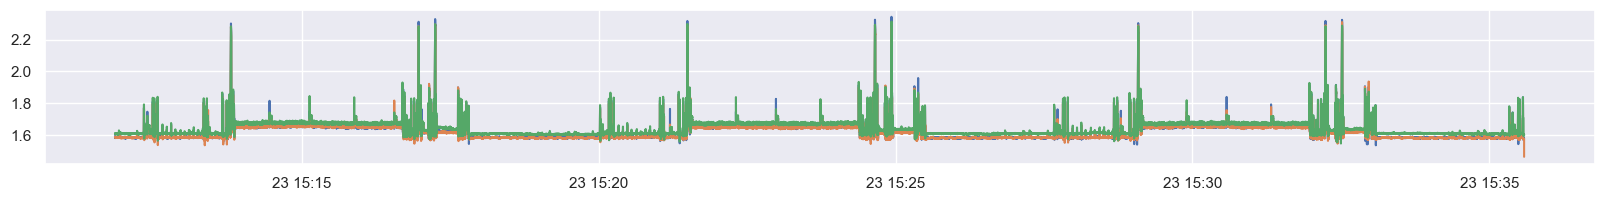

In [38]:
def subsample(vector: np.ndarray, window_size: int) -> np.ndarray:
    return np.array([
        vector[time_step:time_step+window_size].max(axis=0)
        for time_step in range(0, vector.shape[0], window_size) 
    ])

path = "../data/industrial-sensor"
sampling_rate = 200  # 40ms
t = subsample(np.load(f'{path}/t.npy'), window_size=sampling_rate)
X = subsample(np.load(f'{path}/X.npy'), window_size=sampling_rate)

plt.figure(figsize=(20, 2))
plt.plot(t, X);

In [39]:
X.shape

(35600, 3)

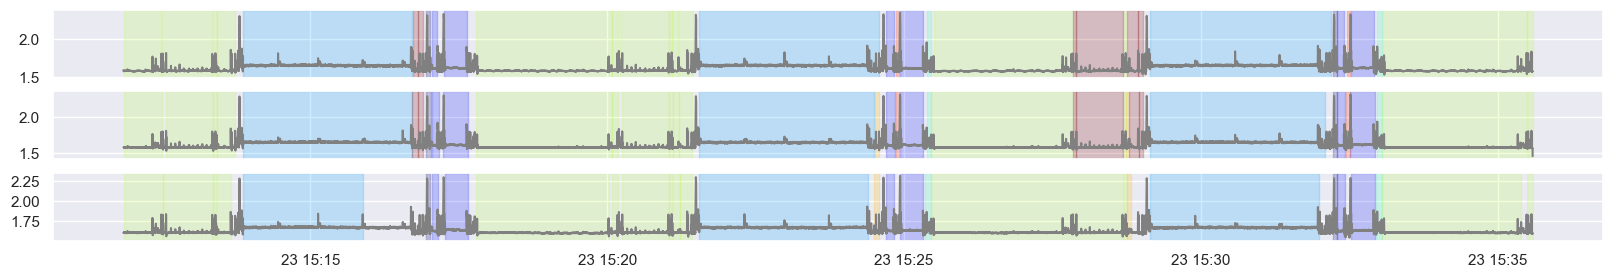

In [40]:
def sec2nb_samples(nb_seconds: int) -> int:
    return int(nb_seconds / (np.diff(t).mean() / np.timedelta64(1, 's')))

# Univariate motif discovery
motif_discovery = BasePersistentPattern(wlen_for_persistence=sec2nb_samples(3), distance_name_for_persistence='Euclidean')
independent_motif_sets = []
for i in range(X.shape[1]):
    mask = np.zeros(X.shape[1])
    mask[i] = True

    motif_discovery.fit(X[:, i].squeeze())
    labels = transform_label(motif_discovery.prediction_mask_)

    independent_motif_sets.append([
        (
            mask,
            np.repeat(
                np.array(motif_set).reshape(len(motif_set), 2, 1),
                mask.sum(),
                axis=-1,
            ),
        )
        for motif_set in labels
    ])

# SubTSMD
subspace_motifs_ = apply_sub_tsmd(independent_motif_sets, 0.5)

# Size constraint
subspace_motifs = [motif_set for motif_set in subspace_motifs_ if motif_set[0].sum() > 1]

# Plotting
plot_motif_sets(X, subspace_motifs, time_steps=t, figsize=(20, 3));

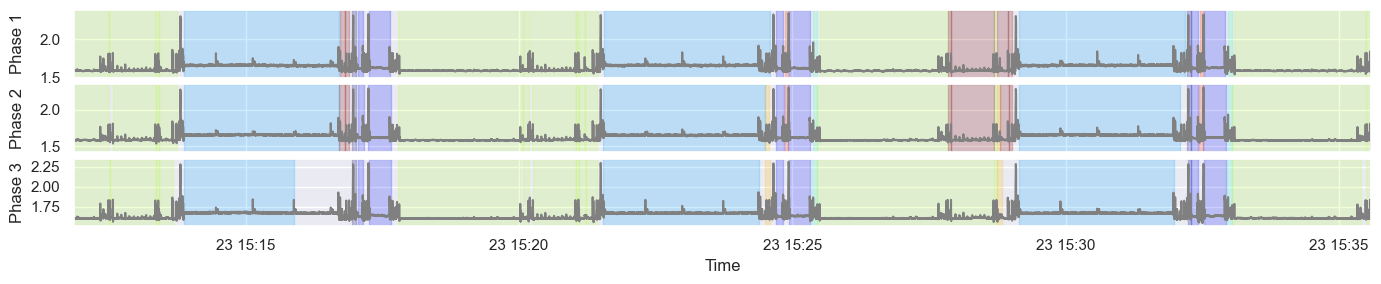

In [59]:
fig = plot_motif_sets(X, subspace_motifs, time_steps=t, figsize=(14, 3))
for i in range(X.shape[1]):
    fig.axes[i].set_ylabel(f"Phase {i+1}")

fig.axes[-1].set_xlim(t[0], t[-1])
fig.axes[-1].set_xlabel("Time")
fig.tight_layout()
fig.align_ylabels()
fig.subplots_adjust(hspace=0.1)
fig.savefig("figures-paper/fig-industrial-sensor-motifs.png", bbox_inches='tight');

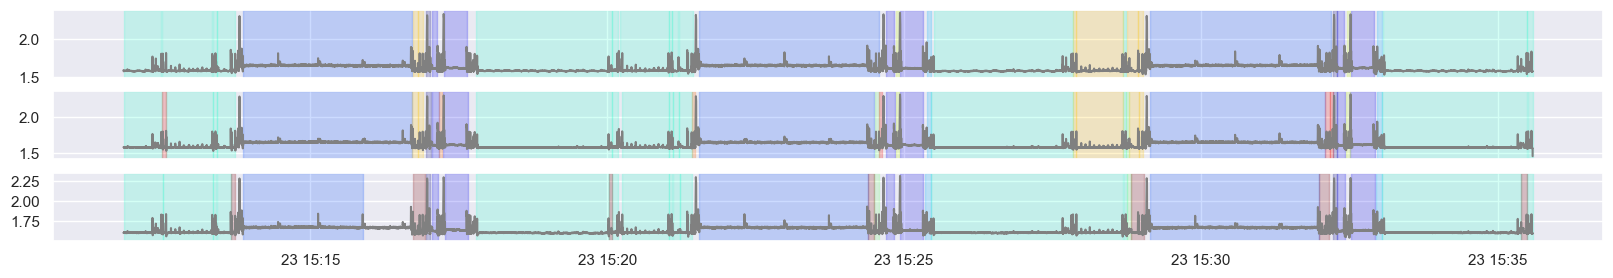

In [41]:
plot_motif_sets(X, subspace_motifs_, time_steps=t, figsize=(20, 3));

In [43]:
len(subspace_motifs_), len(subspace_motifs)

(11, 8)